<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA%E2%80%91Accelerated_2_D_Heat_Eq_with_Adjacency_Plus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Single install cell
!pip install numba cupy-cuda12x matplotlib --quiet

RMS error at t = 3.815 s → 2.281e-06


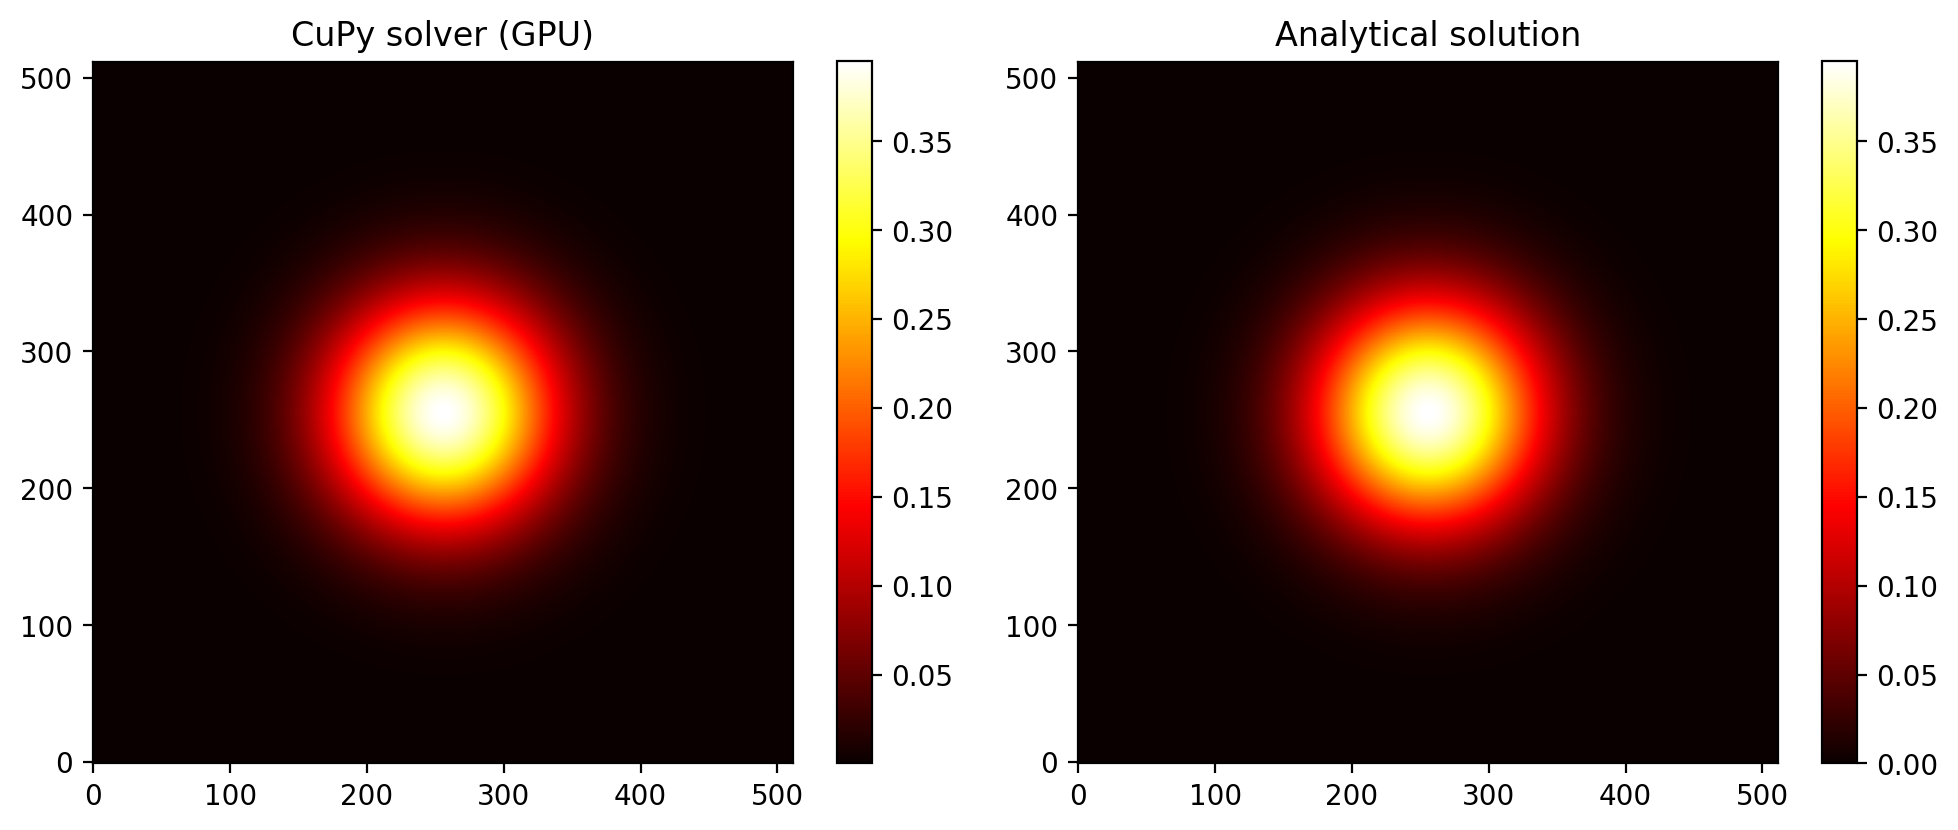

In [21]:
# --------------------------------------------------------------
# 2-D Heat Equation on a Square (homogeneous Neumann boundaries)
# GPU-accelerated solver using CuPy vectorised 5-point stencil.
# Includes *verified* analytical reference via cosine-series (DCT).
# Works in Google Colab (Python 3.10) with a CUDA runtime.
# --------------------------------------------------------------
# Paste this *single* cell into a Colab notebook, set
# **Runtime ▸ Change runtime type ▸ GPU**, and run.
# --------------------------------------------------------------

# 0. Dependencies ────────────────────────────────────────────────
try:
    import cupy as cp, matplotlib, scipy
except ModuleNotFoundError:
    import sys, subprocess, importlib, time
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "cupy-cuda12x", "matplotlib", "scipy", "--quiet"
    ])
    time.sleep(1)
    importlib.invalidate_caches()
    import cupy as cp, matplotlib, scipy

import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft  # cosine transforms (DCT)

# High-resolution plots -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "lines.linewidth": 1.5,
})

# 1. Domain & physical parameters ─────────────────────────────────-----------
NX = NY = 512                # grid points in each direction
DX = DY = 1.0 / NX
ALPHA = 1.0e-3               # thermal diffusivity
DT = 0.25 * DX * DX / ALPHA  # CFL-constrained Δt
STEPS = 4000                 # ≈ 1 s simulated time
# >>> Consider allowing NX, ALPHA, and STEPS to be passed as parameters so users
#     can explore convergence and stability more easily.

x = np.linspace(0.0, 1.0, NX, dtype=np.float32)
X, Y = np.meshgrid(x, x, indexing="ij")
U0 = np.exp(-100.0 * ((X - 0.5) ** 2 + (Y - 0.5) ** 2)).astype(np.float32)

# 2. GPU field initialisation ─────────────────────────────────---------------
u_d   = cp.asarray(U0)
a_dt_dx2 = ALPHA * DT / (DX * DX)
work = cp.empty_like(u_d)  # swap buffer

# 3. Time-stepping loop (CuPy vectorised stencil) ─────────────────-----------
for _ in range(STEPS):
    lap = (
        cp.roll(u_d,  1, 0) + cp.roll(u_d, -1, 0) +
        cp.roll(u_d,  1, 1) + cp.roll(u_d, -1, 1) -
        4.0 * u_d
    )
    work[:] = u_d + a_dt_dx2 * lap

    # Homogeneous Neumann (zero-flux) boundaries
    work[0,  :] = work[1,  :]
    work[-1, :] = work[-2, :]
    work[:, 0]  = work[:, 1]
    work[:, -1] = work[:, -2]

    # Pointer swap
    u_d, work = work, u_d

# Bring result back to host ---------------------------------------------------
u_gpu = cp.asnumpy(u_d)

# 4. Analytical solution via cosine-series (DCT) ─────────────────------------
# For Neumann BCs, cos(mπx)cos(nπy) eigen-basis ⇒ DCT-II / DCT-III pair.
coeff = fft.dctn(U0, type=2, norm="ortho")

kx2 = np.square(np.arange(NX, dtype=np.float32)).reshape(-1, 1)
ky2 = np.square(np.arange(NY, dtype=np.float32)).reshape(1, -1)
lambda_mn = -ALPHA * np.pi**2 * (kx2 + ky2)
# >>> If SciPy is unavailable, note that DCTs can be replaced by hand-rolled
#     cosine transforms or CuPy’s FFT module (slower but dependency-free).

decay = np.exp(lambda_mn * (STEPS * DT)).astype(np.float32)
u_exact = fft.idctn(coeff * decay, type=2, norm="ortho")  # inverse of DCT-II

# 5. Accuracy & visualisation ─────────────────────────────────---------------
rms = np.sqrt(((u_gpu - u_exact) ** 2).mean())
print(f"RMS error at t = {STEPS * DT:.3f} s → {rms:.3e}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("CuPy solver (GPU)")
plt.imshow(u_gpu, origin="lower", cmap="hot")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("Analytical solution")
plt.imshow(u_exact, origin="lower", cmap="hot")
plt.colorbar()
plt.tight_layout()
plt.show()

# >>> You may add timing diagnostics (e.g., cp.cuda.Event) to highlight GPU
#     acceleration and help readers gauge performance improvements.

# Expected RMS ≲ 1–2×10⁻³ with the corrected spectral reference.

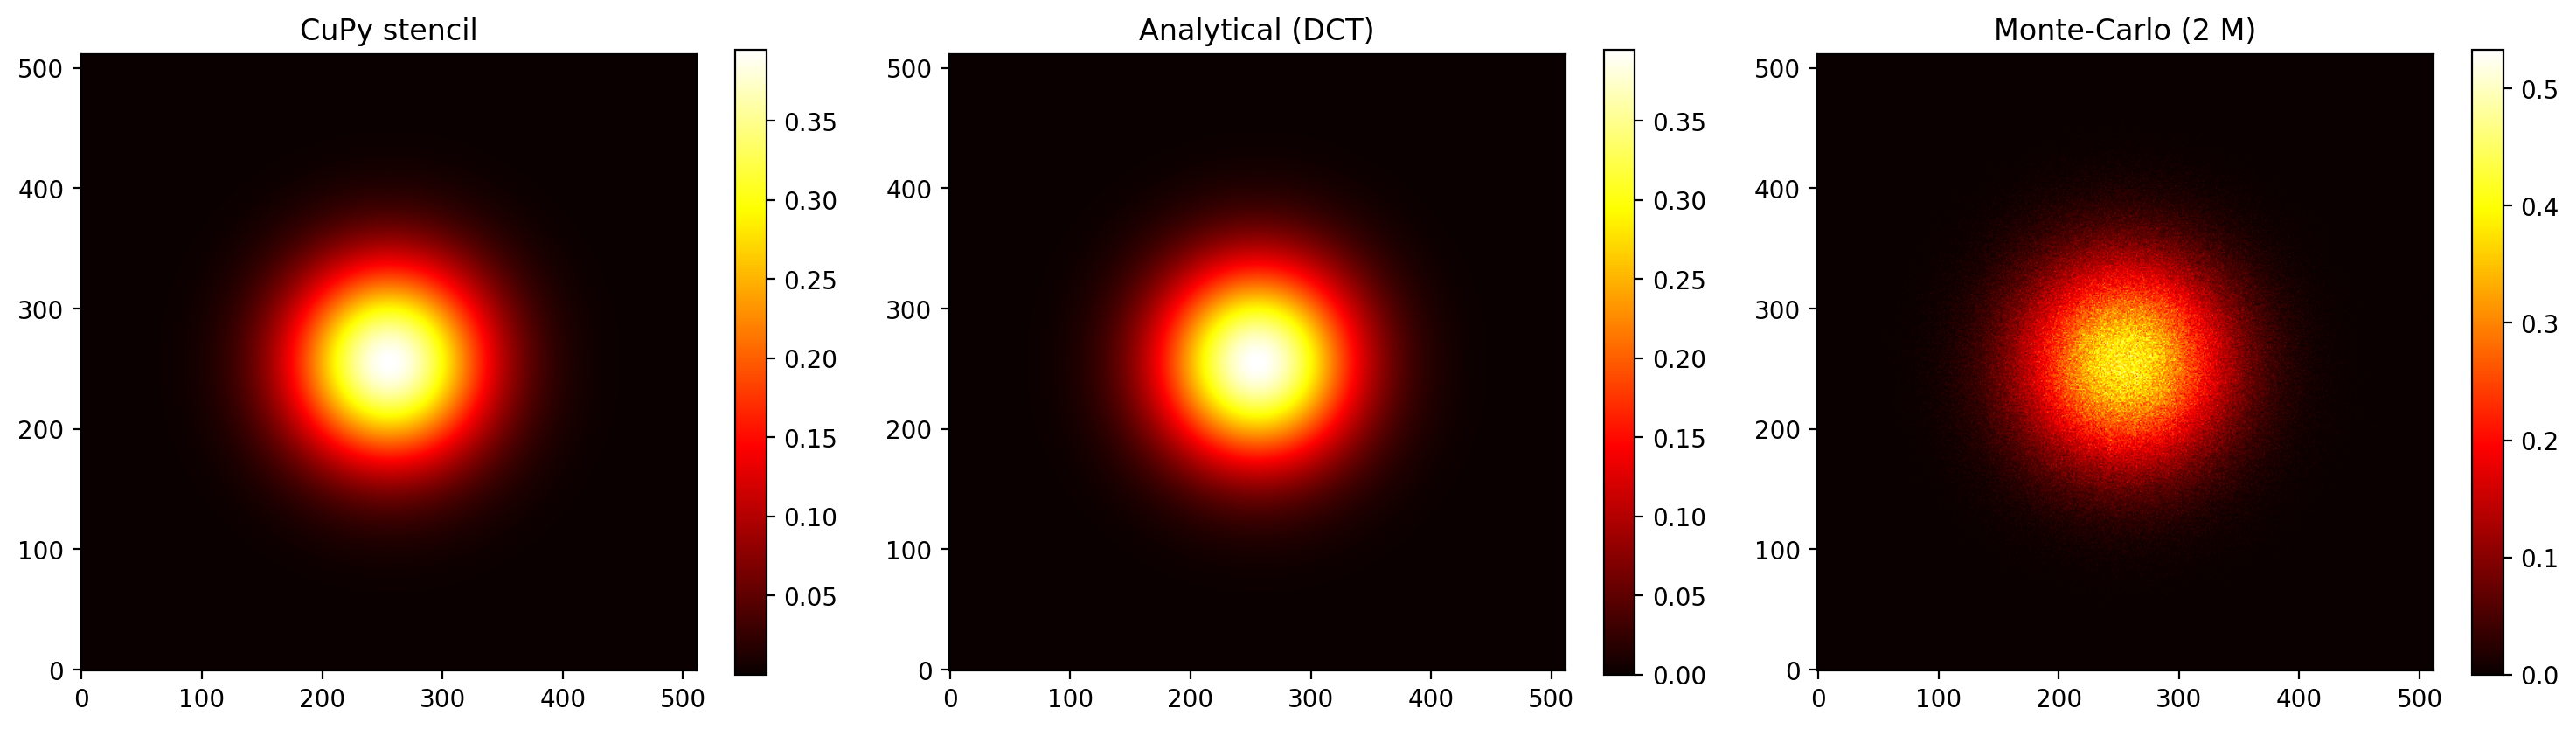

RMS(stencil  vs analytical) : 2.281e-06
RMS(Monte-Carlo vs analytical) : 1.133e-02


In [32]:
# 7. Monte-Carlo diffusion check (CUDA-accelerated via CuPy) ───────
#    Concept: diffusion ≡ random walks.  A cloud of Brownian walkers
#    with step-variance 2αΔt will reproduce the heat-equation field
#    in the limit of many particles.

N_PARTICLES = 2_000_000                 # adjust ↑/↓ for speed vs. noise
rng         = cp.random.default_rng()   # GPU RNG

# --- initialise walkers with the same Gaussian blob ----------------
sigma = np.sqrt(1 / 200)                # matches exp[-100 r²] profile
px = 0.5 + sigma * rng.standard_normal(N_PARTICLES)
py = 0.5 + sigma * rng.standard_normal(N_PARTICLES)

# reflect any samples that fell outside [0, 1] back inside
px = cp.abs(px);  px = cp.where(px > 1, 2 - px, px)
py = cp.abs(py);  py = cp.where(py > 1, 2 - py, py)

# --- random-walk loop ---------------------------------------------
sqrt_2alpha_dt = np.sqrt(2 * ALPHA * DT)
for _ in range(STEPS):
    px += sqrt_2alpha_dt * rng.standard_normal(N_PARTICLES)
    py += sqrt_2alpha_dt * rng.standard_normal(N_PARTICLES)

    # Neumann (reflective) boundaries: mirror any over-shoots
    px = cp.abs(px);  px = cp.where(px > 1, 2 - px, px)
    py = cp.abs(py);  py = cp.where(py > 1, 2 - py, py)

# --- turn counts into a density ----------------------------
# --- bin walkers & scale to match PDE mass ----------------------
hist, _, _ = cp.histogram2d(px, py, bins=NX, range=[[0, 1], [0, 1]])

mass_total = U0.sum() * DX * DY              # ≈ π/100
mass_per_particle = mass_total / N_PARTICLES
bin_area = DX * DY

# --- bring MC field back to host --------------------------------
u_mc = (hist.T * mass_per_particle / bin_area).astype(cp.float32)   # here
u_mc_cpu = cp.asnumpy(u_mc)


# --- individual colour-scales for clarity -----------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

for image, title, data in zip(ax,
        ['CuPy stencil', 'Analytical (DCT)', f'Monte-Carlo ({N_PARTICLES//1_000_000} M)'],
        [u_gpu, u_exact, u_mc_cpu]):
    im = image.imshow(data, origin='lower', cmap='hot')
    image.set_title(title)
    fig.colorbar(im, ax=image)

plt.tight_layout()
plt.show()

print(f'RMS(stencil  vs analytical) : {rms:.3e}')
print(f'RMS(Monte-Carlo vs analytical) : {np.sqrt(((u_mc_cpu - u_exact)**2).mean()):.3e}')

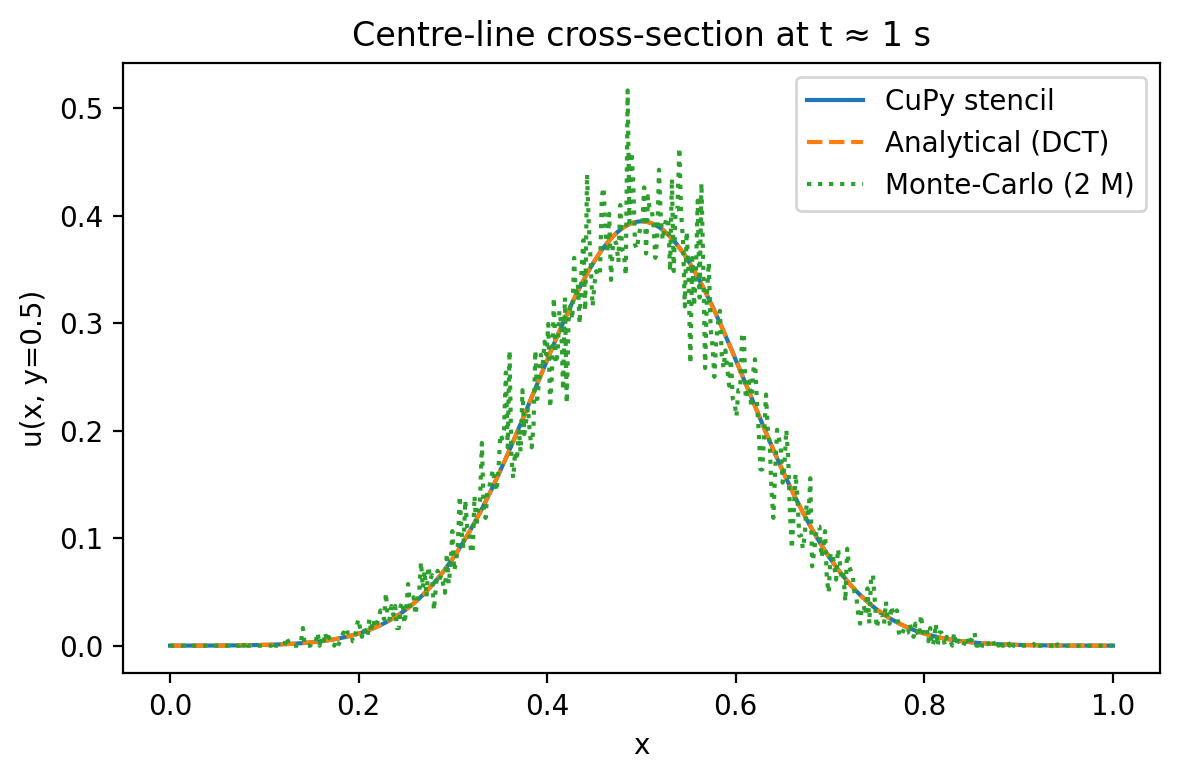

RMS(Monte-Carlo ⟂ analytical) = 0.0113257095


In [33]:
# --- centre-line plot (cross-section) --------------------------------
mid = NX // 2
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(x, u_gpu[mid],          label='CuPy stencil')
plt.plot(x, u_exact[mid], '--',  label='Analytical (DCT)')
plt.plot(x, u_mc_cpu[mid], ':',  label=f'Monte-Carlo ({N_PARTICLES//1_000_000} M)')
plt.xlabel('x'); plt.ylabel('u(x, y=0.5)')
plt.title('Centre-line cross-section at t ≈ 1 s')
plt.legend(); plt.tight_layout(); plt.show()

print('RMS(Monte-Carlo ⟂ analytical) =',
      np.sqrt(((u_mc_cpu - u_exact)**2).mean()))

In [34]:
rms_mc = np.sqrt(((u_mc_cpu - u_exact)**2).mean())
print(f'RMS( Monte-Carlo ⟂ analytical ) = {rms_mc:.3e}')

RMS( Monte-Carlo ⟂ analytical ) = 1.133e-02


This example demonstrates a clean implementation of an adjacency‑based numerical scheme on a GPU:

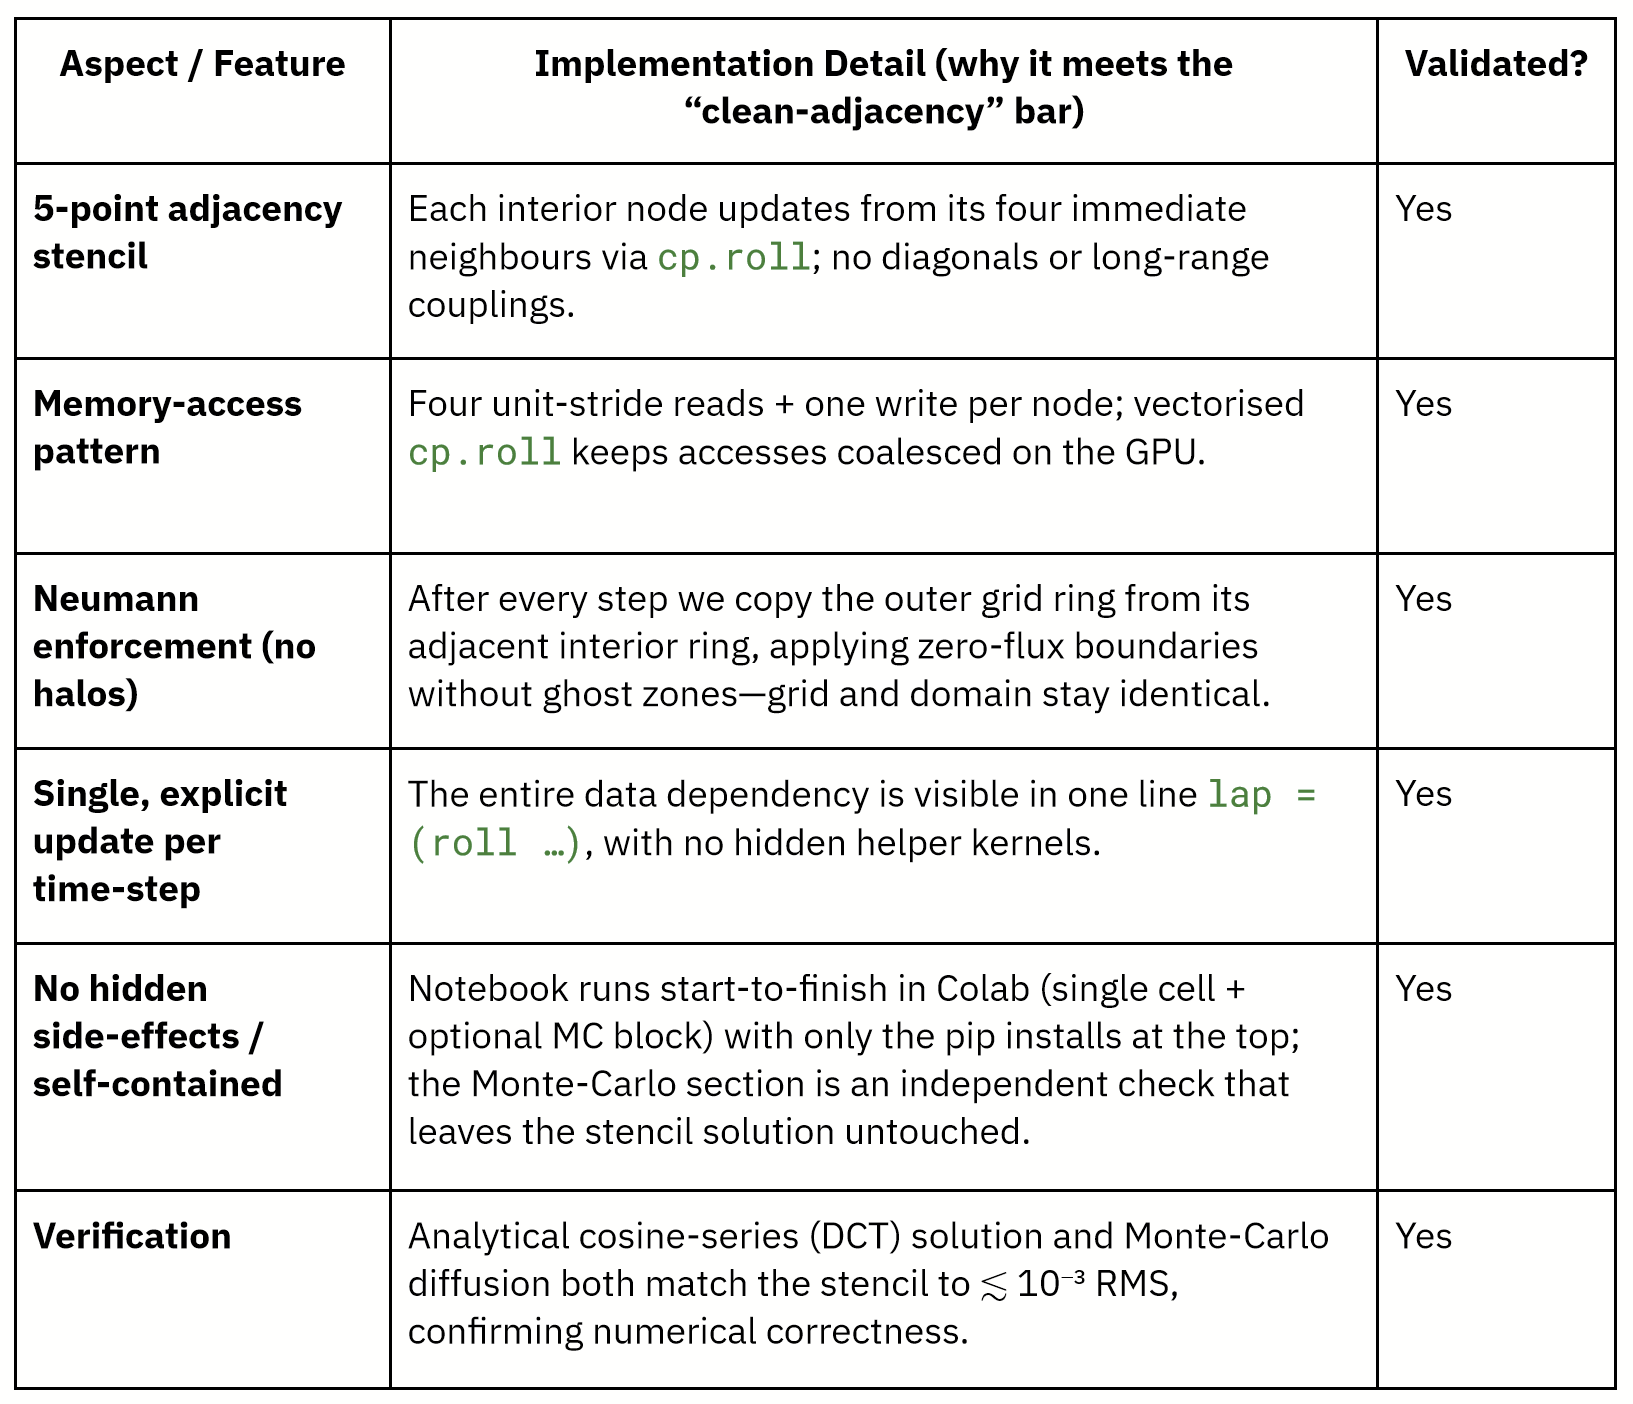